# PART 1: LOAD AND EXPLORE THE DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics 

%matplotlib inline
sns.set_style('whitegrid')


TASK 1: LOAD DATASET INTO DATA FRAME AND PRINT ITS SHAPE AND COLUMN NAME

In [2]:
df = pd.read_csv('USA_Housing.csv')
print(df.shape)
print(df.columns.tolist())

(5000, 7)
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']


TASK 2: DISPLAY FIRST FIVE ROWS, RUN df.info() and df.describe()

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


TASK 3: CHECK FOR MISSING VALUES IN EVERY COLUMN

In [4]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

TASK 4: DROP THE ADDRESS COLUMN

In [5]:
df = df.drop('Address', axis=1)

In [6]:
print(df.columns.tolist())

['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price']


TASK 5: CREATE A HEATMAP OF CORRELATION BETWEEN ALL NUMERIC COLUMNS INCLUDING PRICE

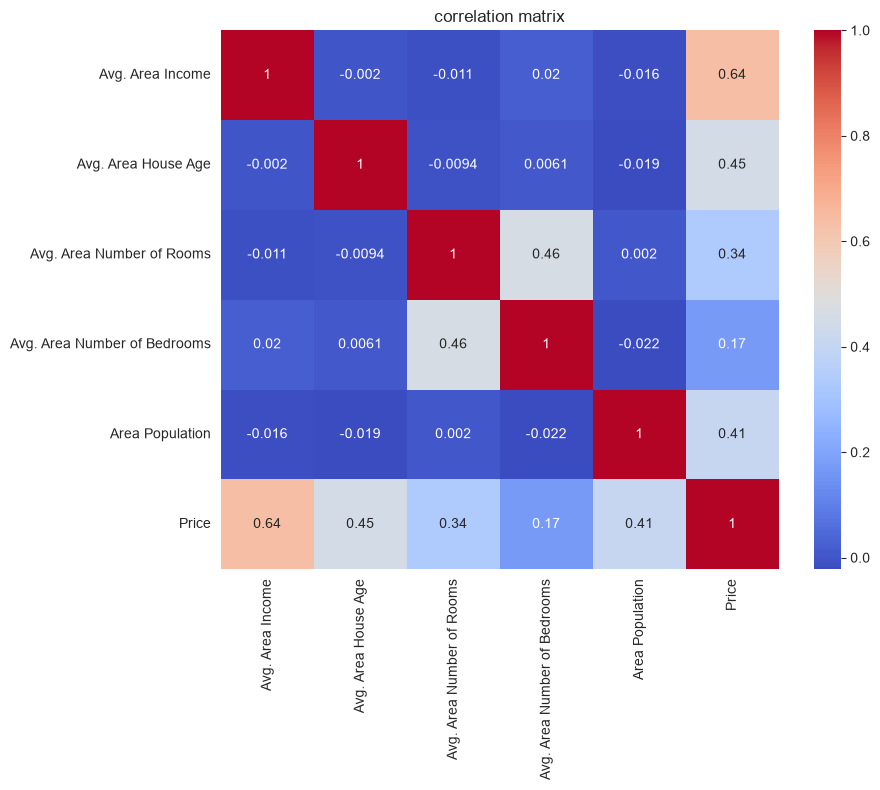

In [7]:

df_corr = df.corr()

plt.figure(figsize=(9,7))
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

Avg.Area Income has the strongest correlation to Price while Avg. Area of Bedroom has the weakest.

# PART 2 - SIMPLE LINEAR REGRESSION
TASK 1: Select Avg.Area Income as X and Price as y

In [8]:
X = df[['Avg. Area Income']]
y = df['Price']

TASK 2: SPLIT THE DATA INTO TRAINING AND TEST SETS

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 4000
Test size: 1000


TASK 3: CREATE AND FIT A LINEAR REGRESSION MODEL ON THE TRAINING DATA 

In [10]:
model_simple = LinearRegression() 
model_simple.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[21.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Avg. Area Income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.251e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


TASK 4:PREDICT ON THE TEST SET THEN PLOT ACTUAL VS PREDICTED VALUES AS A SCATTER PLOT

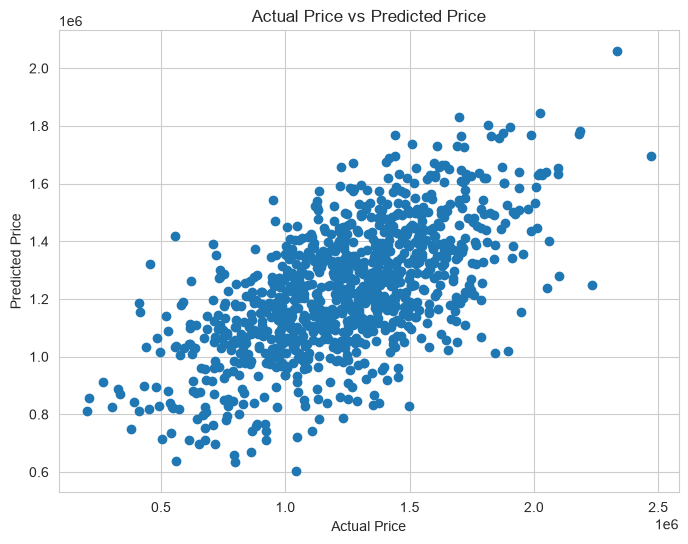

In [21]:
y_pred_simple = model_simple.predict(X_test)
plt.figure(figsize=(8, 6)) 
 
plt.scatter(y_test, y_pred) 
plt.xlabel('Actual Price') 
plt.ylabel('Predicted Price') 
plt.title('Actual Price vs Predicted Price') 
plt.show()

TASK 5: PRINT MODEL COEFFICIENT AND INTERCEPT

In [22]:
print('Coefficient:', model_simple.coef_[0]) 
print('Intercept:', model_simple.intercept_)

Coefficient: 21.208906292657513
Intercept: -225053.70287170145


It shows that for every increase in $1, The Avg. Area Income increases by approximately 21.21

# PART 3: MULTIPLE LINEAR REGRESSION

TASK 1: SELECT ALL NUMERIC FEATURE COLUMNS (EVERYTHING EXCEPT PRICE) as X, and Price as y.

In [13]:
X_multi = df.drop('Price', axis=1) 
y_multi = df['Price']

TASK 2: SPLIT IN TRAINING AND TEST SETS

In [14]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Train size:', X_train_multi.shape[0])
print('Test size:', X_test_multi.shape[0])

Train size: 4000
Test size: 1000


TASK 3: CREATE AND FIT A LINEAR REGRESSION MODEL ON THE TRAINING

In [24]:
model_multi = LinearRegression() 
model_multi.fit(X_train_multi, y_train_multi)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[21.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Avg. Area Income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.251e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


TASK 4: PREDICT ON THE TEST SET

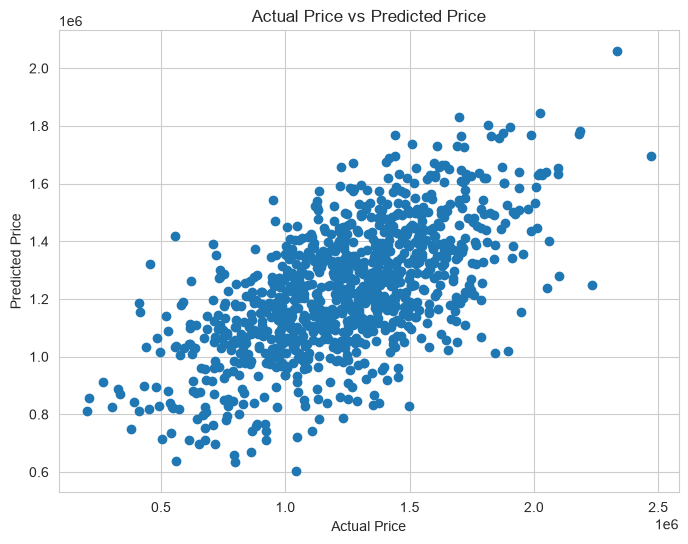

In [23]:
y_pred_multi = model_multi.predict(X_test_multi)
plt.figure(figsize=(8, 6)) 
 
plt.scatter(y_test_multi, y_pred_multi) 
plt.xlabel('Actual Price') 
plt.ylabel('Predicted Price') 
plt.title('Actual Price vs Predicted Price') 
plt.show()

TASK 5:PRINT THE COEFFICIENTS

In [18]:
coeff_df = pd.DataFrame(
    model_multi.coef_, X_multi.columns, columns=['Coefficient']
) 
print(coeff_df)

ValueError: Shape of passed values is (1, 1), indices imply (5, 1)

# PART 4
# TASK 1: Calculate MAE, MSE, RMSE, and R2 for the simple regression model (Part 2).


In [25]:
mae_simple = metrics.mean_absolute_error(y_test, y_pred_simple)
mse_simple = metrics.mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = metrics.r2_score(y_test, y_pred_simple)
print('MAE:', mae_simple)
print('MSE:', mse_simple)
print('RMSE:', rmse_simple)
print('R2:', r2_simple)

MAE: 216826.35309989064
MSE: 74194887058.66
RMSE: 272387.38417676394
R2: 0.39694865192619766


# TASK: Calculate the same four metrics for the multiple regression model (Part 3).

In [26]:
mae_multi = metrics.mean_absolute_error(y_test, y_pred_multi)
mse_multi = metrics.mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = metrics.r2_score(y_test, y_pred_multi)
print('MAE:', mae_multi)
print('MSE:', mse_multi)
print('RMSE:', rmse_multi)
print('R2:', r2_multi)

MAE: 216826.35309989064
MSE: 74194887058.66
RMSE: 272387.38417676394
R2: 0.39694865192619766


# TASK 3: Build a small comparison table showing both models' metrics side by side.

In [27]:
comparison = pd.DataFrame({
'Simple (Income only)': [mae_simple, mse_simple, rmse_simple, r2_simple],
'Multiple (All features)': [mae_multi, mse_multi, rmse_multi, r2_multi]
}, index=['MAE', 'MSE', 'RMSE', 'R2'])
print(comparison)

      Simple (Income only)  Multiple (All features)
MAE           2.168264e+05             2.168264e+05
MSE           7.419489e+10             7.419489e+10
RMSE          2.723874e+05             2.723874e+05
R2            3.969487e-01             3.969487e-01


# TASK 4: Plot a histogram of the residuals (y_test - predictions) for the multiple regression model.

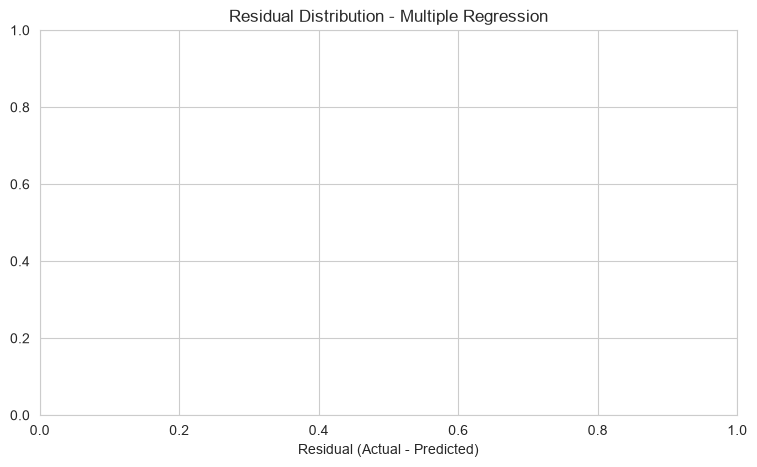

In [28]:
residuals = y_test_multi - y_pred_multi
plt.figure(figsize=(9, 5))
# Your histogram code here
plt.title('Residual Distribution - Multiple Regression')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()

# PART 5:Polynomial Regression - 
# TASK 1:

In [29]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)